In [42]:
# Import necessary libraries for exploratory data analysis (EDA) and plotting
import numpy as np  # Shortened to np
import pandas as pd  # Shortened to pd
import matplotlib.pyplot as plt
import seaborn as sns  # Shortened to snsf

# Ensure plots appear in the notebook
%matplotlib inline

## Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

## Model evaluation tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
# Note: In Scikit-Learn 1.2+, "plot_roc_curve" was changed to "RocCurveDisplay"
from sklearn.metrics import RocCurveDisplay

# Print last updated timestamp
import time
print(f"Last updated: {time.asctime()}")

ibm_analytics =pd.read_csv(r'WA_Fn-UseC_-HR-Employee-Attrition.csv')

Last updated: Sun Feb 22 18:58:26 2026


In [43]:
ibm_analytics.shape

(1470, 35)

In [44]:
ibm_analytics.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [45]:
summary =ibm_analytics.describe()
round(summary,2)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [46]:
ibm_analytics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [47]:
ibm_analytics.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


<Axes: xlabel='Attrition'>

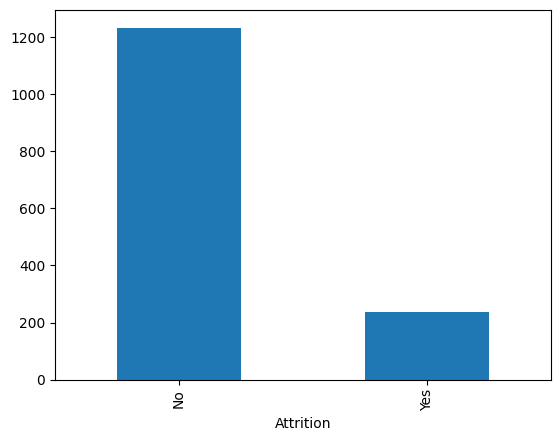

In [48]:
ibm_analytics.Attrition.value_counts().plot(kind='bar')

<Axes: xlabel='Attrition'>

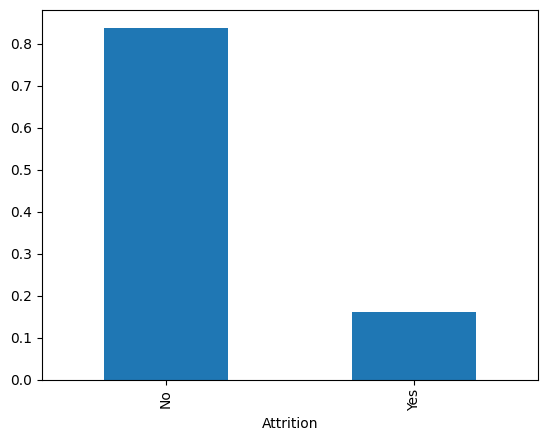

In [49]:
# normalized value counts
ibm_analytics.Attrition.value_counts(normalize=True).plot(kind='bar')

<Axes: xlabel='Gender'>

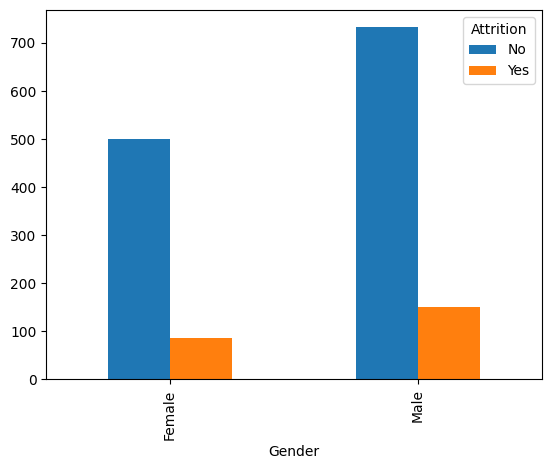

In [50]:
# gender vs attrition
pd.crosstab(ibm_analytics.Gender, ibm_analytics.Attrition).plot(kind='bar')


In [51]:
ibm_analytics.Gender.value_counts()
pd.crosstab( ibm_analytics.Attrition,ibm_analytics.Gender)

# In general more males have more attrition rates than females 17% vs 14.7%

Gender,Female,Male
Attrition,,
No,501,732
Yes,87,150


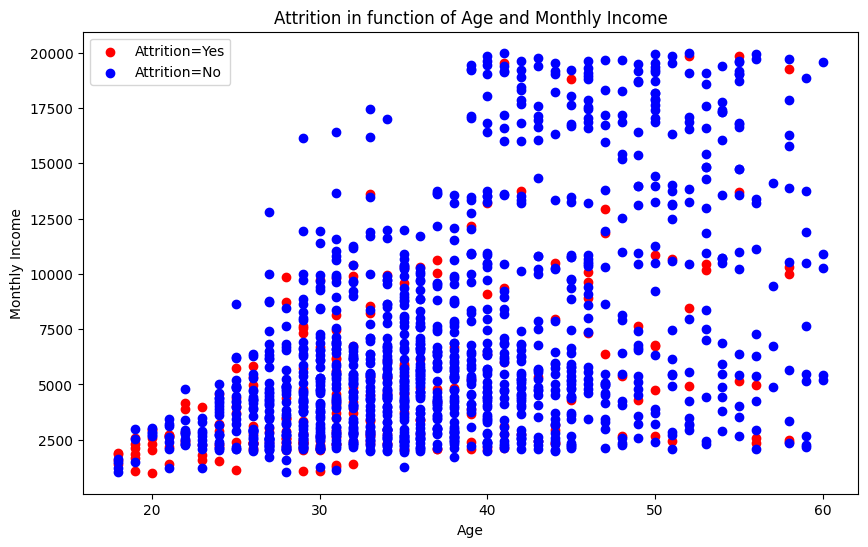

In [52]:
# Age vs attrition scatterplot

plt.figure(figsize=(10,6))

plt.scatter(  ibm_analytics.Age[ibm_analytics.Attrition=='Yes'],
            ibm_analytics.MonthlyIncome[ibm_analytics.Attrition=='Yes'],
            color='red', label='Attrition=Yes')

plt.scatter(  ibm_analytics.Age[ibm_analytics.Attrition=='No'],
            ibm_analytics.MonthlyIncome[ibm_analytics.Attrition=='No'],
            color='blue', label='Attrition=No')

# Add some helpful info
plt.title("Attrition in function of Age and Monthly Income")
plt.xlabel("Age")
plt.legend(["Attrition=Yes", "Attrition=No"])
plt.ylabel("Monthly Income");

<Axes: >

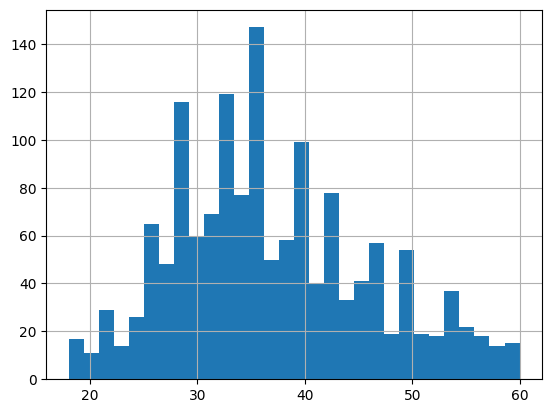

In [53]:
#age distribution

ibm_analytics.Age.hist(bins=30)

In [54]:
# correlation between independent variables

# select numeric columns only to avoid conversion errors
numeric_df = ibm_analytics.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
corr_matrix

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


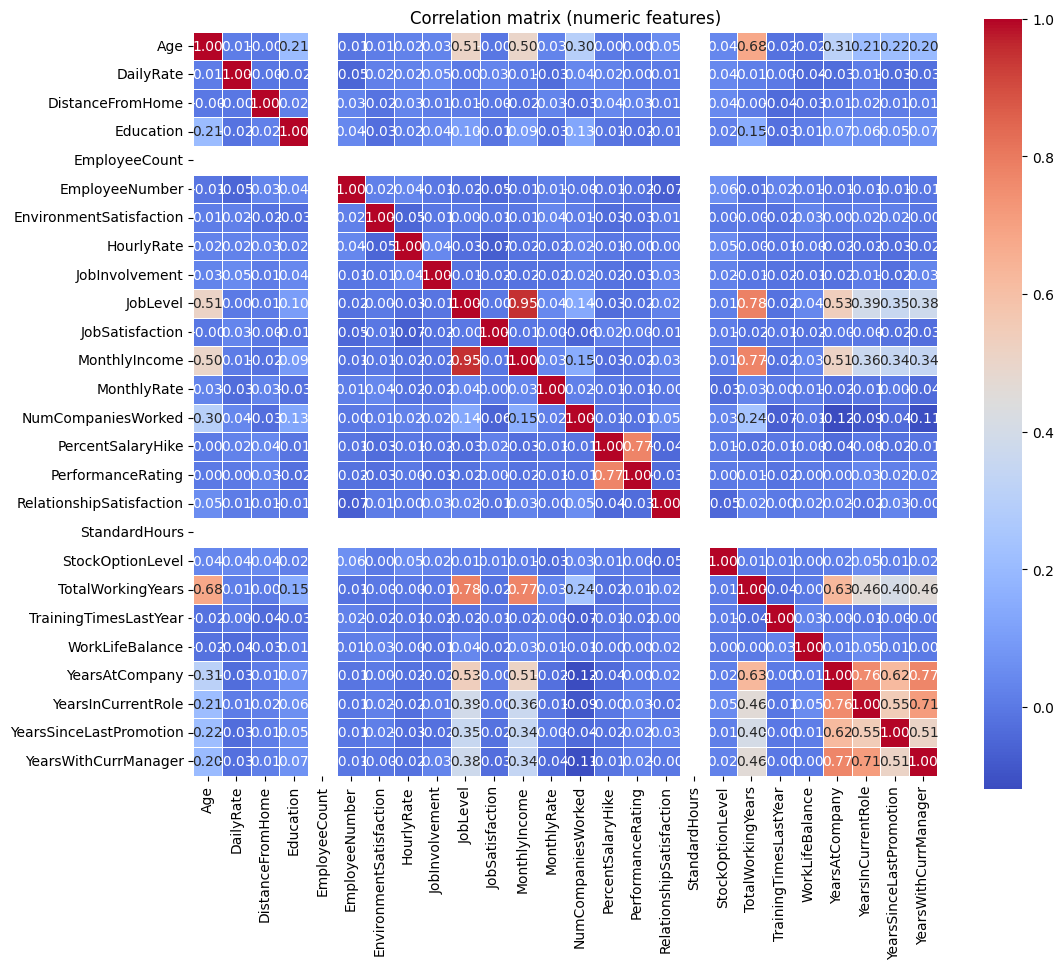

In [55]:
# correlation heatmap for numeric features
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation matrix (numeric features)')
plt.show()

In [56]:
X = ibm_analytics.drop('Attrition', axis=1)
y = ibm_analytics.Attrition

# Encode categorical columns in X
from sklearn.preprocessing import LabelEncoder
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=['object', 'category']).columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

X = X_encoded
X.head()

y.head()

0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: object

In [57]:
np.random.seed(32)

X_Train, X_Test, y_Train, y_Test = train_test_split(X, y, test_size=0.2);

len(X_Train), len(X_Test), len(y_Train), len(y_Test)

(1176, 294, 1176, 294)

In [58]:
X_Train.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1012,31,1,667,2,1,4,1,1,1427,2,...,2,80,0,1,3,3,1,0,0,0
348,42,2,810,1,23,5,1,1,468,1,...,2,80,0,16,2,3,1,0,0,0
672,42,2,462,2,14,2,3,1,936,3,...,1,80,0,10,6,3,5,4,0,3
372,35,2,755,1,9,4,1,1,496,3,...,3,80,0,10,5,3,1,1,0,0
611,35,2,950,1,7,3,4,1,845,3,...,2,80,0,17,3,4,8,5,1,6


In [62]:
models = {"KNN": KNeighborsClassifier(),
          "Logistic Regression": LogisticRegression(), 
          "Random Forest": RandomForestClassifier(),
          "Decision Trees": DecisionTreeClassifier(max_depth=3)}

def fit_and_score(models, X_Train, y_Train, X_Test, y_Test):
    """
    Fits and evaluates given machine learning models.
    
    models: a dict of different Scikit-Learn machine learning models
    X_Train: training data (features)
    y_Train: training data (labels)
    X_Test: test data (features)
    y_Test: test data (labels)
    
    Returns a dictionary of model names and their corresponding accuracy scores.
    """
    np.random.seed(32)
    model_scores = {}
    
    for name, model in models.items():
        # Fit the model to the training data
        model.fit(X_Train, y_Train)
        # Evaluate the model on the test data
        score = model.score(X_Test, y_Test)
        # Store the score in the dictionary
        model_scores[name] = score
        
    return model_scores

In [63]:
model_scores = fit_and_score(models=models, X_Train=X_Train, y_Train=y_Train, X_Test=X_Test, y_Test=y_Test)

model_scores

c:\Users\Admin pc\machine-learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.8129251700680272,
 'Logistic Regression': 0.8163265306122449,
 'Random Forest': 0.8503401360544217,
 'Decision Trees': 0.8367346938775511}

|--- OverTime <= 0.50
|   |--- TotalWorkingYears <= 1.50
|   |   |--- HourlyRate <= 58.50
|   |   |   |--- class: Yes
|   |   |--- HourlyRate >  58.50
|   |   |   |--- class: No
|   |--- TotalWorkingYears >  1.50
|   |   |--- WorkLifeBalance <= 1.50
|   |   |   |--- class: No
|   |   |--- WorkLifeBalance >  1.50
|   |   |   |--- class: No
|--- OverTime >  0.50
|   |--- MonthlyIncome <= 2475.00
|   |   |--- DailyRate <= 931.00
|   |   |   |--- class: Yes
|   |   |--- DailyRate >  931.00
|   |   |   |--- class: No
|   |--- MonthlyIncome >  2475.00
|   |   |--- EnvironmentSatisfaction <= 2.50
|   |   |   |--- class: No
|   |   |--- EnvironmentSatisfaction >  2.50
|   |   |   |--- class: No



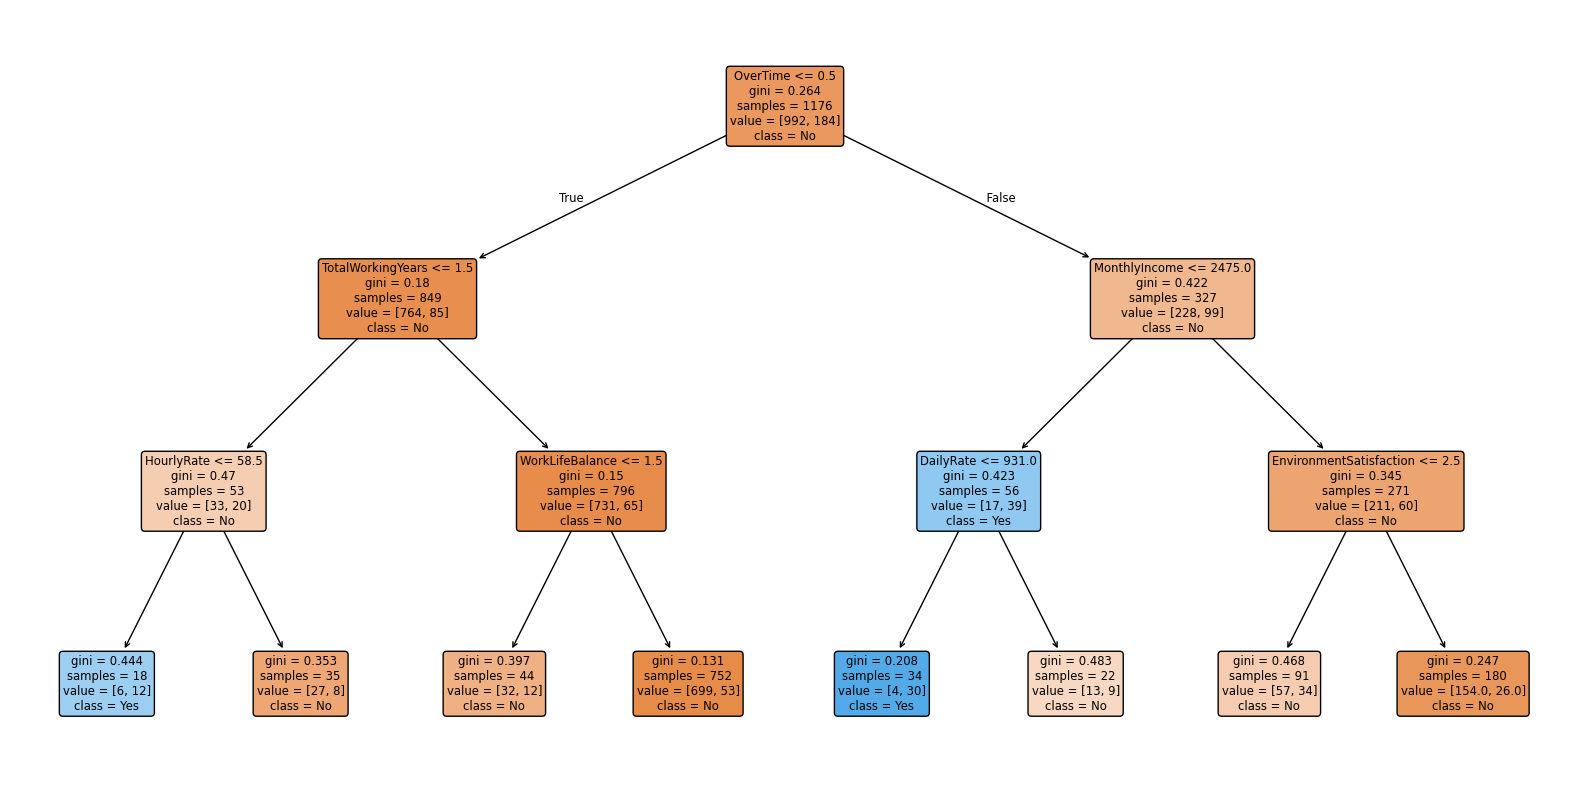

In [64]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text
plt.figure(figsize=(20,10))
plot_tree(models["Decision Trees"], filled=True, feature_names=X.columns, class_names=['No', 'Yes'], rounded=True)
print(export_text(models["Decision Trees"], feature_names=list(X.columns)))

In [66]:
# Descriptive statistics for categorical variables
ibm_analytics.describe(include="object")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [67]:
# Separate variable types
num_cols = ibm_analytics.select_dtypes(include=["int64", "float64"]).columns
cat_cols = ibm_analytics.select_dtypes(include=["object"]).columns

print("Numerical Variables:", len(num_cols))
print("Categorical Variables:", len(cat_cols))

Numerical Variables: 26
Categorical Variables: 9


In [68]:
# Cardinality check
ibm_analytics[cat_cols].nunique().sort_values(ascending=False)

JobRole           9
EducationField    6
MaritalStatus     3
Department        3
BusinessTravel    3
Attrition         2
Gender            2
OverTime          2
Over18            1
dtype: int64

In [69]:
# Check for constant columns
constant_cols = [col for col in ibm_analytics.columns if ibm_analytics[col].nunique() == 1]
constant_cols

['EmployeeCount', 'Over18', 'StandardHours']

In [70]:
# Drop non-informative variables
ibm_analytics = ibm_analytics.drop(["EmployeeCount", "StandardHours", "EmployeeNumber"], axis=1)

# Confirm new shape
ibm_analytics.shape

(1470, 32)

In [71]:
# Redefine feature groups after preprocessing
num_cols = ibm_analytics.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = ibm_analytics.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical Columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [72]:
ibm_analytics.describe()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [73]:
# Drop non-informative columns
cols_to_drop = ["EmployeeCount", "StandardHours", "EmployeeNumber"]
ibm_analytics = ibm_analytics.drop(columns=cols_to_drop, errors="ignore")

In [76]:
cat_cols = [
    "BusinessTravel", "Department", "EducationField", "Gender",
    "JobRole", "MaritalStatus", "Over18", "OverTime"
]

df_encoded = pd.get_dummies(ibm_analytics, columns=cat_cols, drop_first=True)

# Encode target variable (Yes=1, No=0)
df_encoded["Attrition"] = df_encoded["Attrition"].map({"No": 0, "Yes": 1})

df_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [77]:
# Define features and target
X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

# Perform stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [78]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )
}

In [79]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring="roc_auc"
    )
    cv_results[name] = scores.mean()

cv_results_df = pd.DataFrame.from_dict(
    cv_results,
    orient="index",
    columns=["Mean ROC-AUC"]
).sort_values(by="Mean ROC-AUC", ascending=False)

cv_results_df

,Mean ROC-AUC
Logistic Regression,0.823697
Gradient Boosting,0.810744
Random Forest,0.800598


In [80]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

# Train-test split (stratified due to class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1176, 44)
Test size: (294, 44)


In [81]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=1000, random_state=42))
])

# Fit model
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('log_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not 

In [82]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred = final_model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



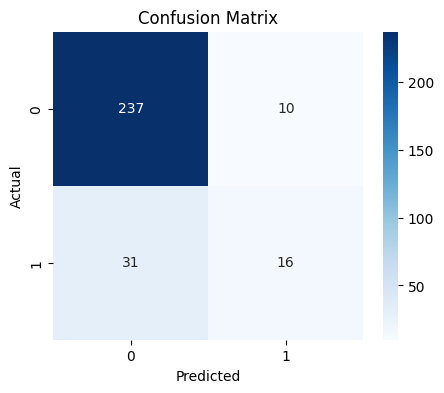

In [83]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual: 0 (No)", "Actual: 1 (Yes)"],
    columns=["Predicted: 0", "Predicted: 1"]
)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

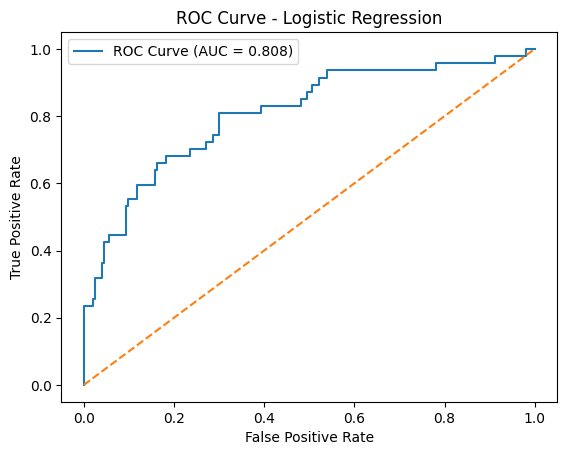

AUC Score: 0.808


In [84]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = final_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("AUC Score:", round(roc_auc, 3))

In [85]:
# Extract trained logistic regression model
log_reg_model = final_model.named_steps["log_reg"]

# Feature names
feature_names = X_train.columns

# Coefficients
coefficients = log_reg_model.coef_[0]

# Create dataframe
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Absolute effect for sorting
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
43,OverTime_Yes,0.864567,0.864567
23,BusinessTravel_Travel_Frequently,0.751247,0.751247
34,JobRole_Laboratory Technician,0.714756,0.714756
16,TotalWorkingYears,-0.555603,0.555603
21,YearsSinceLastPromotion,0.528704,0.528704
11,NumCompaniesWorked,0.487609,0.487609
4,EnvironmentSatisfaction,-0.481659,0.481659
40,JobRole_Sales Representative,0.481459,0.481459
24,BusinessTravel_Travel_Rarely,0.450070,0.450070
8,JobSatisfaction,-0.419417,0.419417


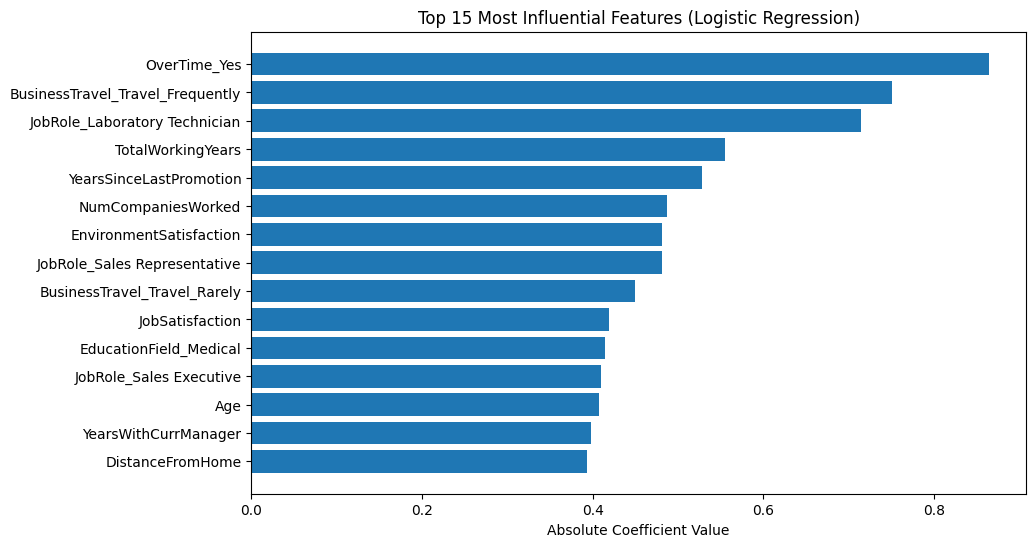

In [87]:
import matplotlib.pyplot as plt

# Top 15 most influential features
top_features = coef_df.sort_values(by="Abs_Coefficient", ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Abs_Coefficient"])
plt.gca().invert_yaxis()
plt.xlabel("Absolute Coefficient Value")
plt.title("Top 15 Most Influential Features (Logistic Regression)")
plt.show()

In [88]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Predict probabilities
y_prob = final_model.predict_proba(X_test)[:, 1]

# Define thresholds
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    results.append((t, precision, recall, f1))

threshold_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "F1"])
threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.336283,0.808511,0.475000
1,0.15,0.367816,0.680851,0.477612
2,0.20,0.434783,0.638298,0.517241
3,0.25,0.482143,0.574468,0.524272
4,0.30,0.510638,0.510638,0.510638
5,0.35,0.488372,0.446809,0.466667
6,0.40,0.567568,0.446809,0.500000
7,0.45,0.633333,0.404255,0.493506
8,0.50,0.615385,0.340426,0.438356
9,0.55,0.652174,0.319149,0.428571


In [89]:
# Choose optimized threshold
optimal_threshold = 0.20

y_pred_opt = (y_prob >= optimal_threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print("Classification Report (Threshold = 0.20):\n")
print(classification_report(y_test, y_pred_opt))

cm_opt = confusion_matrix(y_test, y_pred_opt)
cm_opt

Classification Report (Threshold = 0.20):

              precision    recall  f1-score   support

           0       0.92      0.84      0.88       247
           1       0.43      0.64      0.52        47

    accuracy                           0.81       294
   macro avg       0.68      0.74      0.70       294
weighted avg       0.85      0.81      0.82       294



array([[208,  39],
       [ 17,  30]])